In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# Load Chipotle order dataset
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"
df = pd.read_csv(url, sep='\t')

df.head(10)


,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",$10.98
6,3,1,Side of Chips,NaN,$1.69
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",$11.75
8,4,1,Steak Soft Tacos,"[Tomatillo Green Chili Salsa, [Pinto Beans, Ch...",$9.25
9,5,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Pinto...",$9.25


In [60]:
#Add column named total_price
df['total_price'] = df['quantity'] * df['item_price']
df.head()

,order_id,quantity,item_name,choice_description,item_price,total_price
0,1,1,Chips and Fresh Tomato Salsa,No Description,2.39,2.39
1,1,1,Izze,[Clementine],3.39,3.39
2,1,1,Nantucket Nectar,[Apple],3.39,3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,No Description,2.39,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98,33.96


In [57]:
#Remove the $ so the script can calculate item_price

# Check if item_price is of object (string) type before applying .str accessor
if pd.api.types.is_string_dtype(df['item_price']):
    df['item_price'] = df['item_price'].str.replace('$','', regex=False).astype('float')

#Changed the 'NaN' so the list looks clean
df = df.fillna({
    'choice_description': 'No Description'
})

In [64]:
#Group the item_name with their item_price
ave_price = df.groupby('item_name')['total_price'].sum().reset_index()
#Isolate the top 5 selling items
top_5 = ave_price.sort_values('total_price', ascending=False).head(5)
top_5


,item_name,total_price
17,Chicken Bowl,8044.63
18,Chicken Burrito,6387.06
39,Steak Burrito,4236.13
38,Steak Bowl,2479.81
25,Chips and Guacamole,2475.62


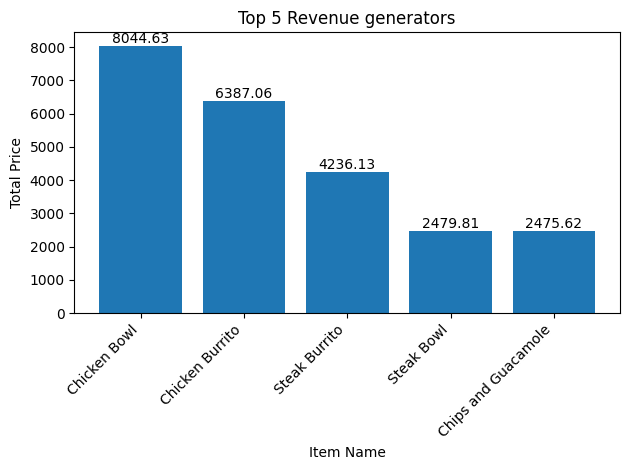

In [65]:
# Draw vertical bar chart: plt.bar(x_axis, y_axis)
plt.bar(top_5['item_name'], top_5['total_price'])
plt.title('Top 5 Revenue generators')
plt.xlabel('Item Name')
plt.ylabel('Total Price')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels


# Add numerical labels on top of the bars, rounded to 2 decimal places
for index, item_name_val in enumerate(top_5['item_name']):
    item_price_val = top_5['total_price'].iloc[index]
    plt.text(index, item_price_val + 0.5, str(round(item_price_val, 2)), ha='center', va='bottom')

plt.tight_layout() # Adjust layout to prevent labels from being cut off
# Display the chart on screen
plt.show()